# Introduction
This notebook covers main functions of `numcompute_stream`

It couvers the requirements by showing how to:

- Loads a dataset from a CSV file using `io.py` `load_stream_csv` (io.py)

- Splits the dataset into multiple chunks to simulate a streaming data setting
  - Train a ensemble method using Bagging
  - Train a ensemble method using Random Forest

- Trains the pipeline incrementally using `.partial_fit()` on each chunk

- Demonstrate memory footprint after training

- Visualises key metrics over time
  - `plot_metric_over_time` plot a graphic on accuracy and rolling_accuracy over time
  - `compare_models` compare two models on precisions and f1
  - `plot_predictions_vs_ground_truth` plot a scatter graphic to show predictions and Ground truth  

- Show stats of chunks
  - `stats.py` `get_meanVar()` show overall mean and variance
  - `stats.py` `get_quantiles()` show quantiles of the latest window_sized chunk
  - `stats.py` `get_histograms()` show histogram of the latest window_sized chunk

- Preprocess data
  - show the numeric fill_value(mean)
  - show the category fill_value(mode)
  - show categories for transforming onehot

# 1. Enviroment setup
import all required modules and libraries
- `io.py` demonstrate first five rows of the data

In [1]:
import sys
import numpy as np
sys.path.append("..")

from numcompute_stream.io import load_stream_csv
from numcompute_stream.stream import StreamTrainer
from numcompute_stream.pipeline import PipeLine, Preprocessor
from numcompute_stream.ensemble import EnsembleClassifier
from numcompute_stream.tree import DecisionTreeClassifier
from numcompute_stream.metrics import StreamMetrics
from numcompute_stream.visualise import plot_metric_over_time, plot_predictions_vs_ground_truth, compare_models

In [2]:
data_path = '../data/adult.csv'
stream_chunk = load_stream_csv(data_path, chunk_size=100)
X_chunk, y_chunk = next(stream_chunk)

print('X_chunk\n',X_chunk[:5,:])
print('y_chunk\n',y_chunk[:5])

print('Features number:\n',X_chunk.shape[1])
print('Classification distribution:\n',np.unique(y_chunk))

X_chunk
 [['25' 'Private' '226802' '11th' '7' 'Never-married' 'Machine-op-inspct'
  'Own-child' 'Black' 'Male' '0' '0' '40' 'United-States']
 ['38' 'Private' '89814' 'HS-grad' '9' 'Married-civ-spouse'
  'Farming-fishing' 'Husband' 'White' 'Male' '0' '0' '50' 'United-States']
 ['28' 'Local-gov' '336951' 'Assoc-acdm' '12' 'Married-civ-spouse'
  'Protective-serv' 'Husband' 'White' 'Male' '0' '0' '40' 'United-States']
 ['44' 'Private' '160323' 'Some-college' '10' 'Married-civ-spouse'
  'Machine-op-inspct' 'Husband' 'Black' 'Male' '7688' '0' '40'
  'United-States']
 ['18' '' '103497' 'Some-college' '10' 'Never-married' '' 'Own-child'
  'White' 'Female' '0' '0' '30' 'United-States']]
y_chunk
 ['<=50K' '<=50K' '>50K' '>50K' '<=50K']
Features number:
 14
Classification distribution:
 ['<=50K' '>50K']


# 2. Build pipeline
Build two pipelines
- Bagging pipeline
  - `Preprocessor()` preprocess X_chunk
  - `EnsembleClassifier()`
    - `n_estimators` five trees
    - `max_depth` max_depth is five
    - `min_samples_split` min_samples_split is two
    - `window_size` buffering window size is five

- Random Forest pipeline
  - `Preprocessor()` preprocess X_chunk
  - `EnsembleClassifier()`
    - `n_estimators` five trees
    - `max_depth` max_depth is five
    - `min_samples_split` min_samples_split is two
    - `window_size` buffering window size is five
    - `max_features` choose 4 random features for every training

In [3]:
# Bagging
pipe_bag = PipeLine([
    ('preprocessor',Preprocessor()),
    ('classifier',EnsembleClassifier(
        base_tree=DecisionTreeClassifier,
        n_estimators=5,
        max_depth=5,
        min_samples_split=2,
        max_features=None,
        window_size = 5
    ))
])

# RF
pipe_rf = PipeLine([
    ('preprocessor',Preprocessor()),
    ('classifier',EnsembleClassifier(
        base_tree=DecisionTreeClassifier,
        n_estimators=5,
        max_depth=5,
        min_samples_split=2,
        max_features=4,
        window_size = 5
    ))
])

metrics_bag = StreamMetrics(n_class=2, window_size=5)
metrics_rf = StreamMetrics(n_class=2, window_size=5)

train_bag = StreamTrainer(pipe_bag, metrics_bag)
train_rf = StreamTrainer(pipe_rf, metrics_rf)

# 3. Build the training chain

- Fit the X_chunk and y_chunk into two pipelines
- Every `chunk_size` is 2000
- Print accuracy every three chunks

In [4]:
chunk_count = 0

for X_chunk, y_chunk in load_stream_csv(data_path, chunk_size=2000):
    train_bag.score_chunk(X_chunk, y_chunk)
    train_rf.score_chunk(X_chunk, y_chunk)
    
    train_bag.fit_chunk(X_chunk, y_chunk)
    train_rf.fit_chunk(X_chunk, y_chunk)
    
    chunk_count += 1
    
    if train_bag.logs and chunk_count % 3 ==0: 
        acc_bag = train_bag.logs[-1]['accuracy']
        acc_rf = train_rf.logs[-1]['accuracy']
        print(f'Bagging accuracy:{acc_bag}, RF accuracy:{acc_rf}')
    

Bagging accuracy:0.84325, RF accuracy:0.7755
Bagging accuracy:0.845, RF accuracy:0.79
Bagging accuracy:0.844, RF accuracy:0.782875
Bagging accuracy:0.8444090909090909, RF accuracy:0.7814545454545454
Bagging accuracy:0.8428571428571429, RF accuracy:0.7829642857142857
Bagging accuracy:0.8440882352941177, RF accuracy:0.7840588235294118
Bagging accuracy:0.844825, RF accuracy:0.78325
Bagging accuracy:0.8451521739130434, RF accuracy:0.7820217391304348


# 4. Metrics

Show relevant metrics of two models

**Bagging** and **Random Forest**:
- Total training time(senconds)
- Total memory usage(MB)
- accuracy
- precision
- recall
- f1
- rolling_accuracy
- rolling_precision
- rolling_recall
- rolling_f1

In [5]:
def metrics_summary(model_name, trainer):
    print("#"*20)
    print(f'\n{model_name}')
    
    result = trainer.metrics.result()
    total_trainin_time = sum(trainer.training_time)
    total_memory_usage = sum(trainer.memory)
    
    print(f'Total training time(senconds):{total_trainin_time}')
    print(f'Total memory usage(MB):{total_memory_usage}')
    
    print(f'accuracy:{result["accuracy"]:.2f}')
    print(f'precision:{np.mean(result["precision"]):.2f}')
    print(f'recall:{np.mean(result["recall"]):.2f}')
    print(f'f1:{np.mean(result["f1"]):.2f}')
    
    if 'rolling_accuracy' in result:
        print(f'rolling_accuracy:{result["rolling_accuracy"]:.2f}')
        print(f'rolling_precision:{np.mean(result["rolling_precision"]):.2f}')
        print(f'rolling_recall:{np.mean(result["rolling_recall"]):.2f}')
        print(f'rolling_f1:{np.mean(result["rolling_f1"]):.2f}')
        
metrics_summary('Bagging',train_bag)
metrics_summary('Random forest',train_rf)

####################

Bagging
Total training time(senconds):2501.8927
Total memory usage(MB):790.9665
accuracy:0.84
precision:0.81
recall:0.74
f1:0.76
rolling_accuracy:0.84
rolling_precision:0.81
rolling_recall:0.74
rolling_f1:0.76
####################

Random forest
Total training time(senconds):107.7711
Total memory usage(MB):1058.624
accuracy:0.78
precision:0.80
recall:0.55
f1:0.54
rolling_accuracy:0.78
rolling_precision:0.84
rolling_recall:0.55
rolling_f1:0.53


# 5. Visualization
- Visualises key metrics over time
  - `plot_metric_over_time` plot a graphic on accuracy and rolling_accuracy over time
  - `compare_models` compare two models on precisions and f1
  - `plot_predictions_vs_ground_truth` plot a scatter graphic to show predictions and Ground truth

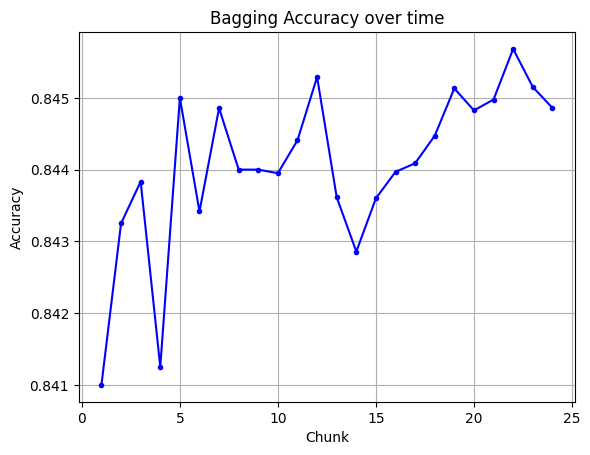

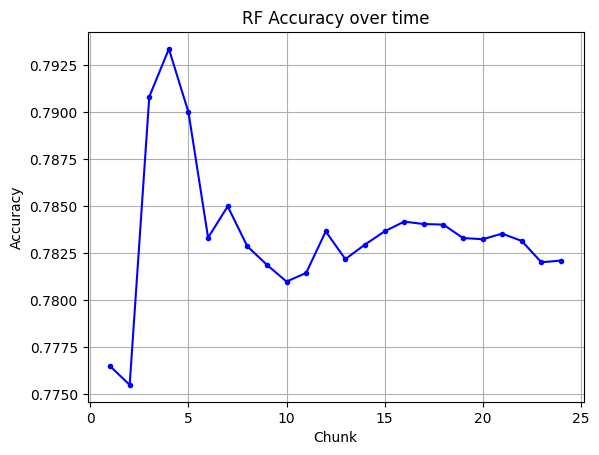

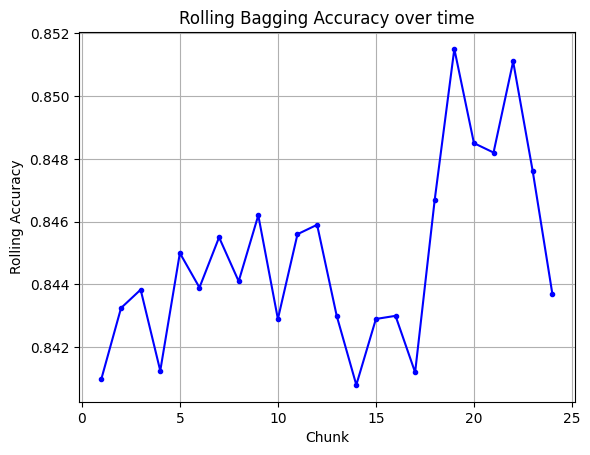

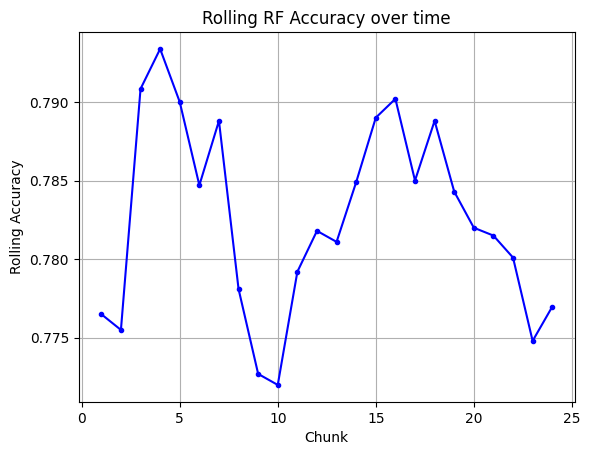

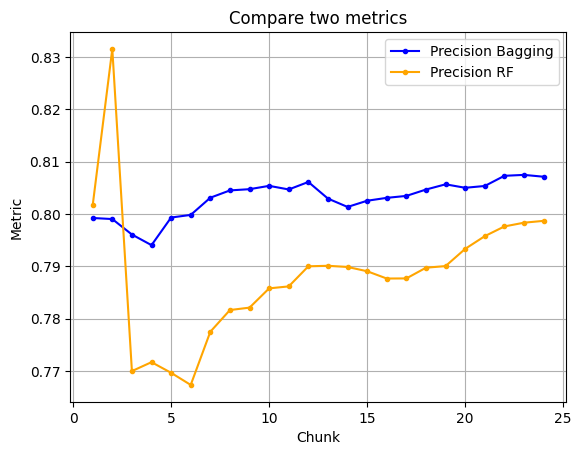

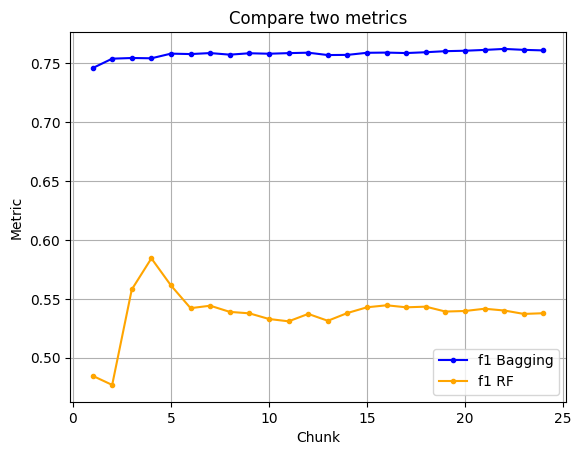

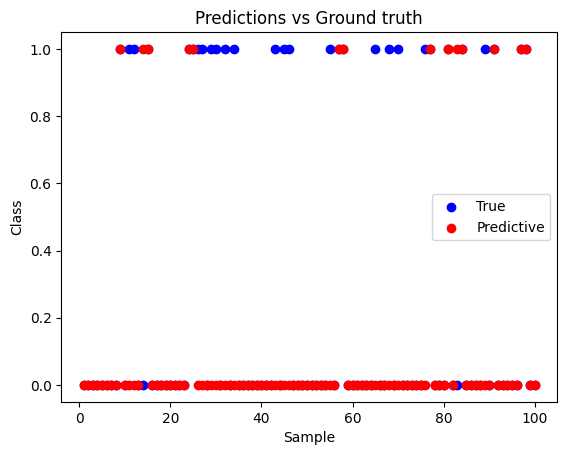

In [6]:
acc_bag = [log['accuracy'] for log in train_bag.logs]
acc_rf = [log['accuracy'] for log in train_rf.logs]

rolling_acc_bag = [log['rolling_accuracy'] for log in train_bag.logs]
rolling_acc_rf = [log['rolling_accuracy'] for log in train_rf.logs]

pre_bag = [log['precision'] for log in train_bag.logs]
pre_rf = [log['precision'] for log in train_rf.logs]


f1_bag = [log['f1'] for log in train_bag.logs]
f1_rf = [log['f1'] for log in train_rf.logs]


plot_metric_over_time(acc_bag, 'Bagging Accuracy over time', 'Accuracy')
plot_metric_over_time(acc_rf, 'RF Accuracy over time', 'Accuracy')

plot_metric_over_time(rolling_acc_bag, 'Rolling Bagging Accuracy over time', 'Rolling Accuracy')
plot_metric_over_time(rolling_acc_rf, 'Rolling RF Accuracy over time', 'Rolling Accuracy')

compare_models(pre_bag, pre_rf, ['Precision Bagging','Precision RF'])
compare_models(f1_bag, f1_rf, ['f1 Bagging','f1 RF'])

y_pred_last = train_bag.pipeline.predict(X_chunk)
le = train_bag.pipeline.label_encoder
plot_predictions_vs_ground_truth(le.transform(y_chunk)[:100], le.transform(y_pred_last)[:100])

# 6.Stats

- Show stats of chunks
  - `stats.py` `get_meanVar()` show overall mean and variance
  - `stats.py` `get_quantiles()` show quantiles of the latest window_sized chunk
  - `stats.py` `get_histograms()` show histogram of the latest window_sized chunk

In [16]:
preprocessor = train_bag.pipeline.steps[0][1]
stream_stats = preprocessor.scaler.stats

mean, variance = stream_stats.get_meanVar()

q25 = stream_stats.get_quantiles(0.25)
q50 = stream_stats.get_quantiles(0.5)

histogram = stream_stats.get_histograms()


print(f'Mean: {np.round(mean,2)} \nvariance: {np.round(variance,2)}')
print(f'\nQuantile of 0.25:{np.round(q25,2)}')
print(f'\nQuantile of 0.5:{np.round(q50,2)}')
print('\nHistogram(last chunk)')

for i, (hist, edges) in enumerate(histogram):
    print(f'  Feature {i}: counts={hist}, edges={np.round(edges, 2)}')

Mean: [3.8640000e+01 1.8966413e+05 1.0080000e+01 1.0790700e+03 8.7500000e+01
 4.0420000e+01] 
variance: [1.87970000e+02 1.11519819e+10 6.61000000e+00 5.55314510e+07
 1.62409340e+05 1.53540000e+02]

Quantile of 0.25:[2.90000e+01 1.16621e+05 9.00000e+00 0.00000e+00 0.00000e+00 3.80000e+01]

Quantile of 0.5:[3.850000e+01 1.758975e+05 1.000000e+01 0.000000e+00 0.000000e+00
 4.000000e+01]

Histogram(last chunk)
  Feature 0: counts=[269 322 188  55   8], edges=[17.  31.6 46.2 60.8 75.4 90. ]
  Feature 1: counts=[595 225  18   3   1], edges=[ 23776.  215346.4 406916.8 598487.2 790057.6 981628. ]
  Feature 2: counts=[ 18  55 288 262 219], edges=[ 1.  4.  7. 10. 13. 16.]
  Feature 3: counts=[835   2   0   0   5], edges=[    0.  19999.8 39999.6 59999.4 79999.2 99999. ]
  Feature 4: counts=[799   1   5  29   8], edges=[   0.   511.8 1023.6 1535.4 2047.2 2559. ]
  Feature 5: counts=[ 79 496 193  64  10], edges=[ 1.  20.6 40.2 59.8 79.4 99. ]


# 7. Preprocessor

- Preprocess data
  - show the numeric fill_value(mean)
  - show the category fill_value(mode)
  - show categories for transforming onehot

In [21]:
preprocessor = train_bag.pipeline.steps[0][1]

mean_fill = preprocessor.num_imputer.means
cat_fill = preprocessor.cat_imputer.fill_values
one_hot_transform = preprocessor.encoder.categories

print('\nNumerical imputer for filling means')
for i, v in enumerate(mean_fill):
    print(f'Feature{i}:{np.round(v,2)}')

print('\nCategory imputer for filling frequent categories')
for i, v in enumerate(cat_fill):
    print(f'Feature{i}:{v}')

print('\nOneHotEncoder for transforming data')
for i, v in enumerate(one_hot_transform):
    print(f'Feature{i} ({len(v)}categories):{list(v)}')


Numerical imputer for filling means
Feature0:38.64
Feature1:189664.13
Feature2:10.08
Feature3:1079.07
Feature4:87.5
Feature5:40.42

Category imputer for filling frequent categories
Feature0:Private
Feature1:HS-grad
Feature2:Married-civ-spouse
Feature3:Prof-specialty
Feature4:Husband
Feature5:White
Feature6:Male
Feature7:United-States

OneHotEncoder for transforming data
Feature0 (6categories):[np.str_('Federal-gov'), np.str_('Local-gov'), np.str_('Private'), np.str_('Self-emp-inc'), np.str_('Self-emp-not-inc'), np.str_('State-gov')]
Feature1 (16categories):[np.str_('10th'), np.str_('11th'), np.str_('12th'), np.str_('1st-4th'), np.str_('5th-6th'), np.str_('7th-8th'), np.str_('9th'), np.str_('Assoc-acdm'), np.str_('Assoc-voc'), np.str_('Bachelors'), np.str_('Doctorate'), np.str_('HS-grad'), np.str_('Masters'), np.str_('Preschool'), np.str_('Prof-school'), np.str_('Some-college')]
Feature2 (7categories):[np.str_('Divorced'), np.str_('Married-AF-spouse'), np.str_('Married-civ-spouse'), np

# 10 Summary

This assignment aims to familiarize students with the basic knowledge of machine learning by asking students to implement all chain ways of ensemble method of decision tree(Bagging and Random forest). And visualize relevant metrics after training

- As is shown in Metrics cell
  - Bagging used more total training time with higher accuracy
  - Random Forest used more total memory usage with less accuracy

- As is shown in Visualisation cell
  - Bagging has more higher and robust f1 and accuracy, which means bagging may have better performance on the same configurations
  - And the reason why the random forest have worse accuracy is beacause we set the n_estimator as the low number(As usual, the n_estimator is 100)